In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset
shipment = pd.read_csv("ShipmentDelivery_Cleaned.csv")
shipment.head()

,Shipment_ID,Customer,Warehouse_ID,Destination_Region,Dispatch_Date,Delivery_Date,Delivery_Time_Days,Weight,Carrier_Name,Shipment_Status,Delivery_Mode,Shipment_Cost,Delivery_Accuracy_Flag,Damage_Flag
0,S000001,V55555_53,PLANT16,PORT09,2024-12-15,2024-12-18,3,14.30,V44_3,Delivered,AIR,1.4992,1,0
1,S000002,V55555_53,PLANT16,PORT09,2023-03-28,2023-04-01,4,87.94,V44_3,Delivered,AIR,1.4992,1,0
2,S000003,V55555_53,PLANT16,PORT09,2024-01-19,2024-01-24,5,61.20,V44_3,Delivered,AIR,1.4992,1,1
3,S000004,V55555_53,PLANT16,PORT09,2023-10-21,2023-10-26,5,16.16,V44_3,Delivered,AIR,1.4992,1,0
4,S000005,V55555_53,PLANT16,PORT09,2024-07-21,2024-07-24,3,52.34,V44_3,Delivered,AIR,1.4992,1,0


In [ ]:
# load dataset
warehouse = pd.read_csv("WarehouseOperations_Cleaned.csv")
warehouse.head()

,Warehouse_ID,Warehouse_Capacity_Units,Current_Inventory_Units,Inventory_Turnover_Ratio,Order_Fulfilment_Rate,Avg_Pick_Pack_Time_Min,Warehouse_Utilization_Percentage,Labour_Hours_Per_Day,Operational_Cost_Per_Day
0,PLANT15,246,149,2.81904,100.0,22,60.57,3,42.17
1,PLANT17,179,112,2.81904,100.0,24,62.57,3,9.61
2,PLANT18,2488,2041,2.81904,100.0,24,82.03,4,831.20
3,PLANT05,8631,6252,2.81904,100.0,23,72.44,12,610.38
4,PLANT02,3094,1780,2.81904,100.0,25,57.53,3,169.99


In [ ]:
# Merging both dataset
shipment_ml = shipment.merge(
    warehouse,
    on="Warehouse_ID",
    how="left"
)

In [ ]:
shipment_ml.head()

,Shipment_ID,Customer,Warehouse_ID,Destination_Region,Dispatch_Date,Delivery_Date,Delivery_Time_Days,Weight,Carrier_Name,Shipment_Status,...,Delivery_Accuracy_Flag,Damage_Flag,Warehouse_Capacity_Units,Current_Inventory_Units,Inventory_Turnover_Ratio,Order_Fulfilment_Rate,Avg_Pick_Pack_Time_Min,Warehouse_Utilization_Percentage,Labour_Hours_Per_Day,Operational_Cost_Per_Day
0,S000001,V55555_53,PLANT16,PORT09,2024-12-15,2024-12-18,3,14.30,V44_3,Delivered,...,1,0,134299,69792,0.01,100.0,28,51.97,139,26797.44
1,S000002,V55555_53,PLANT16,PORT09,2023-03-28,2023-04-01,4,87.94,V44_3,Delivered,...,1,0,134299,69792,0.01,100.0,28,51.97,139,26797.44
2,S000003,V55555_53,PLANT16,PORT09,2024-01-19,2024-01-24,5,61.20,V44_3,Delivered,...,1,1,134299,69792,0.01,100.0,28,51.97,139,26797.44
3,S000004,V55555_53,PLANT16,PORT09,2023-10-21,2023-10-26,5,16.16,V44_3,Delivered,...,1,0,134299,69792,0.01,100.0,28,51.97,139,26797.44
4,S000005,V55555_53,PLANT16,PORT09,2024-07-21,2024-07-24,3,52.34,V44_3,Delivered,...,1,0,134299,69792,0.01,100.0,28,51.97,139,26797.44


In [ ]:
# Convert the date columns

shipment_ml["Dispatch_Date"] = pd.to_datetime(shipment_ml["Dispatch_Date"])
shipment_ml["Delivery_Date"] = pd.to_datetime(shipment_ml["Delivery_Date"])

In [ ]:
# create new features
shipment_ml["Dispatch_Month"] = shipment_ml["Dispatch_Date"].dt.month

shipment_ml["Dispatch_Day"] = shipment_ml["Dispatch_Date"].dt.day

shipment_ml["Dispatch_Weekday"] = shipment_ml["Dispatch_Date"].dt.dayofweek

shipment_ml["Dispatch_Quarter"] = shipment_ml["Dispatch_Date"].dt.quarter

In [ ]:
# Select Features

features = [

    "Weight",

    "Carrier_Name",

    "Delivery_Mode",

    "Warehouse_ID",

    "Destination_Region",

    "Delivery_Time_Days",

    "Warehouse_Utilization_Percentage",

    "Inventory_Turnover_Ratio",

    "Order_Fulfilment_Rate",

    "Avg_Pick_Pack_Time_Min",

    "Operational_Cost_Per_Day",

    "Dispatch_Month",

    "Dispatch_Weekday",

    "Dispatch_Quarter"

]

In [ ]:
# target
target = "Shipment_Cost"

In [ ]:
# create X and Y
X = shipment_ml[features]

y = shipment_ml[target]

In [ ]:
# Encoding Categorical Variables

from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.select_dtypes(include="object").columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

    encoders[col] = le

/tmp/ipykernel_1065/4161794134.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_1065/4161794134.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_1065/4161794134.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [ ]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [ ]:
# Train Linear Regressor
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
#Train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
# Model Evaluation Function

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

import numpy as np

def evaluate(name,y_test,pred):

    mae = mean_absolute_error(y_test,pred)

    rmse = np.sqrt(mean_squared_error(y_test,pred))

    r2 = r2_score(y_test,pred)

    print(name)

    print("MAE :",mae)

    print("RMSE :",rmse)

    print("R2 :",r2)

    print("-"*40)

    return [name,mae,rmse,r2]

In [ ]:
lr_result = evaluate(

    "Linear Regression",

    y_test,

    lr_pred

)

rf_result = evaluate(

    "Random Forest",

    y_test,

    rf_pred
)

Linear Regression
MAE : 15.464715067101235
RMSE : 46.125158974660735
R2 : -2.5690266958061985
----------------------------------------
Random Forest
MAE : 10.95856143932722
RMSE : 20.77483410688676
R2 : 0.2759823167849347
----------------------------------------


**Interpretation:**

Shipment cost could not be predicted accurately using a simple

linear model.

The negative R² score indicates that Linear Regression is not suitable for this dataset.

Random Forest achieved lower prediction errors than Linear Regression.

It captured the non-linear relationship between shipment features and shipment cost more effectively.

In [ ]:
comparison = pd.DataFrame(

    [lr_result,rf_result],

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2 Score"

    ]

)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,15.464715,46.125159,-2.569027
1,Random Forest,10.958561,20.774834,0.275982


In [ ]:
# Feature Importance Plot
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
0,Weight,0.940448
2,Delivery_Mode,0.031760
1,Carrier_Name,0.011153
5,Delivery_Time_Days,0.008285
11,Dispatch_Month,0.006370
13,Dispatch_Quarter,0.001153
12,Dispatch_Weekday,0.000550
6,Warehouse_Utilization_Percentage,0.000131
3,Warehouse_ID,0.000065
10,Operational_Cost_Per_Day,0.000038


**Interpretations:**

Shipment Weight is the most important factor affecting shipment cost.

Delivery Mode and Carrier Name also influence shipment cost, but to a lesser extent.

Other features have a comparatively smaller impact on the prediction.

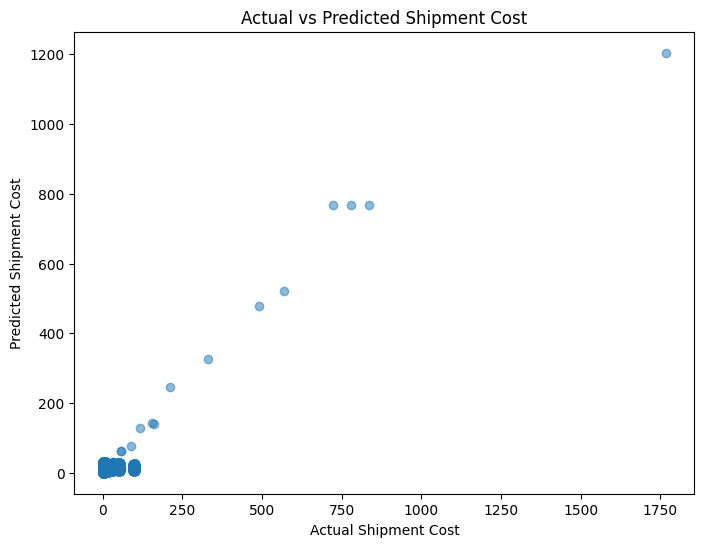

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    rf_pred,

    alpha=0.5

)

plt.xlabel("Actual Shipment Cost")

plt.ylabel("Predicted Shipment Cost")

plt.title("Actual vs Predicted Shipment Cost")

plt.show()

**Interpretation:**

Most predicted shipment costs are close to the actual values.

The model performs well for common shipment costs but is less accurate for some high-cost shipments

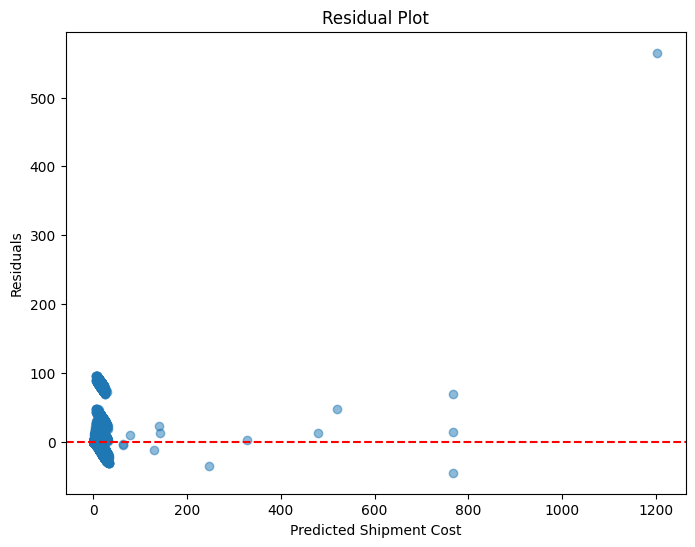

In [ ]:
# Residual Plot
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(rf_pred, residuals, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Shipment Cost")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

**Interpretations:**

Most prediction errors are close to zero, indicating reasonable model performance.

Larger errors occur only for a few high-cost shipments.

In [ ]:
# Summary

print(comparison)

print("\nTop Important Features")

print(importance.head(10))


               Model        MAE       RMSE  R2 Score
0  Linear Regression  15.464715  46.125159 -2.569027
1      Random Forest  10.958561  20.774834  0.275982

Top Important Features
                             Feature  Importance
0                             Weight    0.940448
2                      Delivery_Mode    0.031760
1                       Carrier_Name    0.011153
5                 Delivery_Time_Days    0.008285
11                    Dispatch_Month    0.006370
13                  Dispatch_Quarter    0.001153
12                  Dispatch_Weekday    0.000550
6   Warehouse_Utilization_Percentage    0.000131
3                       Warehouse_ID    0.000065
10          Operational_Cost_Per_Day    0.000038


**Key Findings:**

* Random Forest performed better than Linear Regression for shipment cost prediction.
* Shipment Weight was identified as the strongest predictor of shipment cost.
* The model can help estimate transportation costs before shipment planning.






**Business Recommendations:**

* Use the Random Forest model for shipment cost estimation.
* Monitor shipment weight during planning, as it has the highest impact on logistics cost.
* Include additional variables such as route distance, fuel cost, weather, and traffic in future models to improve prediction accuracy.

In [ ]:
# Simple Linear Regression
# Using Weight as the single predictor

X_simple = shipment[["Weight"]]
y_simple = shipment["Shipment_Cost"]

In [ ]:
# 60% Train, 20% Validation, 20% Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X_simple,
    y_simple,
    test_size=0.40,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (125641, 1)
Validation set: (41880, 1)
Testing set: (41881, 1)


In [ ]:
from sklearn.linear_model import LinearRegression

simple_lr = LinearRegression()

simple_lr.fit(X_train, y_train)

val_pred = simple_lr.predict(X_val)
test_pred = simple_lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_r2 = r2_score(y_val, val_pred)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

print("Validation Results")
print("MAE :", val_mae)
print("RMSE :", val_rmse)
print("R2 :", val_r2)

print("\nTest Results")
print("MAE :", test_mae)
print("RMSE :", test_rmse)
print("R2 :", test_r2)

Validation Results
MAE : 14.604028526006253
RMSE : 41.41816199447437
R2 : -0.5301309027778018

Test Results
MAE : 14.418263686356168
RMSE : 34.451763685038216
R2 : -1.0708209030274372


In [ ]:
print("Intercept:", simple_lr.intercept_)
print("Weight Coefficient:", simple_lr.coef_[0])

print(
    f"Shipment Cost = {simple_lr.intercept_:.2f} "
    f"+ ({simple_lr.coef_[0]:.2f} × Weight)"
)

Intercept: 2.0789014040716527
Weight Coefficient: 0.5084425525926966
Shipment Cost = 2.08 + (0.51 × Weight)


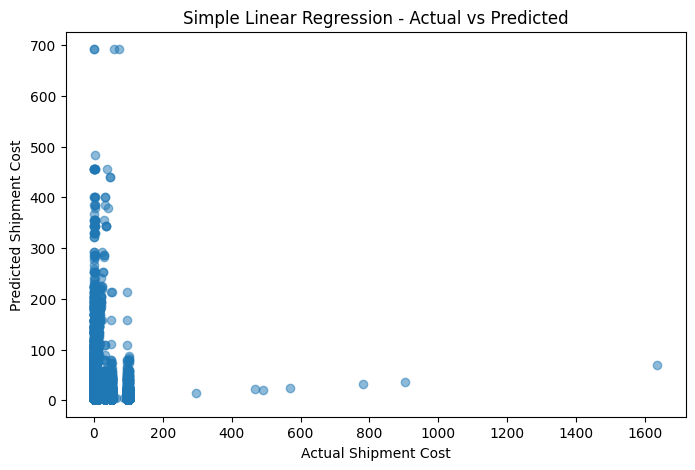

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, test_pred, alpha=0.5)

plt.xlabel("Actual Shipment Cost")
plt.ylabel("Predicted Shipment Cost")
plt.title("Simple Linear Regression - Actual vs Predicted")

plt.show()

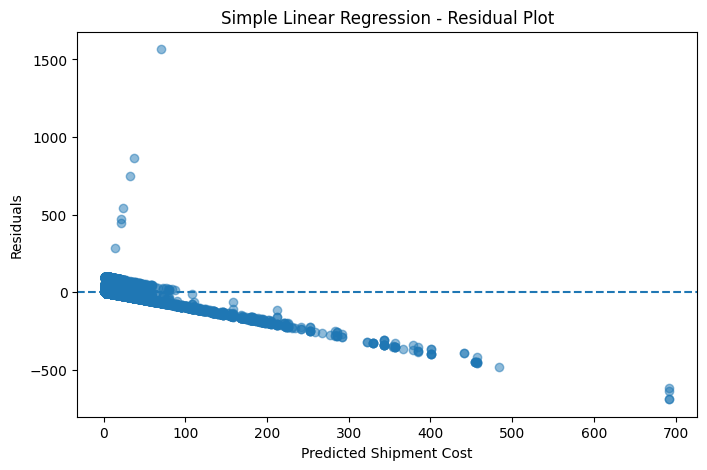

In [ ]:
residuals = y_test - test_pred

plt.figure(figsize=(8,5))

plt.scatter(test_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Shipment Cost")
plt.ylabel("Residuals")
plt.title("Simple Linear Regression - Residual Plot")

plt.show()

In [ ]:
simple_lr_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Validation": [val_mae, val_rmse, val_r2],
    "Test": [test_mae, test_rmse, test_r2]
})

simple_lr_results

,Metric,Validation,Test
0,MAE,14.604029,14.418264
1,RMSE,41.418162,34.451764
2,R2 Score,-0.530131,-1.070821


**Interpretations:**

•	The test MAE of 14.42 means the model's predictions differ from actual shipment cost by about 14.42 cost units on average.

•	The test RMSE of 34.45 indicates that some predictions have substantially larger errors.

•	The negative test R² of -1.07 shows that Weight alone is not sufficient to reliably predict Shipment Cost.

•	The Actual vs Predicted and residual plots show considerable prediction errors, supporting the conclusion that other factors influence shipment cost.

•	The result is useful as a baseline because it shows the limitation of predicting shipment cost from a single variable.
